<a href="https://colab.research.google.com/github/marvelpokemaster/BRATS/blob/main/FineTuned_DenseNet201_PCA_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuned DenseNet201 + PCA + SVM Brain Tumor Classification

In [14]:

!pip install tensorflow scikit-learn seaborn
!rm -rf brain-tumor-mris*
!curl -L -o ./brain-tumor-mris.zip https://www.kaggle.com/api/v1/datasets/download/vinayjayanti/brain-tumor-mris
!unzip -q ./brain-tumor-mris.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  127M  100  127M    0     0   139M      0 --:--:-- --:--:-- --:--:--  190M
replace brain_tumor_mris/Testing/glioma/Te-gl_0010.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [15]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:

train_data = './brain_tumor_mris/Training'
test_data = './brain_tumor_mris/Testing'
validation_data = './brain_tumor_mris/Validation'

img_width = 224
img_height = 224
batch_size = 32
epochs = 20


In [17]:

datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = datagen.flow_from_directory(
    train_data,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

validation_generator = datagen.flow_from_directory(
    validation_data,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_data,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 4672 images belonging to 4 classes.
Found 576 images belonging to 4 classes.
Found 576 images belonging to 4 classes.


## Fine-Tuning DenseNet201

In [18]:
base_model = DenseNet201(
    weights='imagenet',
    include_top=False,
    pooling='avg', # This already does the Global Average Pooling for you
    input_shape=(224,224,3)
)

base_model.trainable = True

# Freeze all but the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Build the model WITHOUT the extra GlobalAveragePooling2D layer
fine_tune_model = models.Sequential([
    base_model,
    # layers.GlobalAveragePooling2D(),  <-- DELETE OR COMMENT OUT THIS LINE
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

from tensorflow.keras.optimizers import Adam

fine_tune_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Now run the fit
history = fine_tune_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    verbose=1
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 110s 319ms/step - accuracy: 0.2432 - loss: 1.6941 - val_accuracy: 0.2917 - val_loss: 1.3780
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 22s 151ms/step - accuracy: 0.3367 - loss: 1.3765 - val_accuracy: 0.4010 - val_loss: 1.2867
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 22s 152ms/step - accuracy: 0.4197 - loss: 1.2746 - val_accuracy: 0.4045 - val_loss: 1.2503
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - accuracy: 0.4675 - loss: 1.2043 - val_accuracy: 0.4479 - val_loss: 1.1751
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.5539 - loss: 1.1015 - val_accuracy: 0.6285 - val_loss: 1.0693
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - accuracy: 0.6145 - loss: 1.0070 - val_accuracy: 0.6337 - val_loss: 1.0241
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.6592 - loss: 0.9159 - val_accuracy: 0.6215 - val_loss: 1.0560
Epoch 8/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.6916 - loss: 

## Feature Extraction using Fine-Tuned Weights

In [19]:

feature_extractor = models.Model(
    inputs=fine_tune_model.layers[0].input,
    outputs=base_model.output
)

train_features = feature_extractor.predict(train_generator, verbose=1)
validation_features = feature_extractor.predict(validation_generator, verbose=1)
test_features = feature_extractor.predict(test_generator, verbose=1)

# train_features = train_features.reshape(train_features.shape[0], -1)
# validation_features = validation_features.reshape(validation_features.shape[0], -1)
# test_features = test_features.reshape(test_features.shape[0], -1)

train_labels = train_generator.classes
validation_labels = validation_generator.classes
test_labels = test_generator.classes


146/146 ━━━━━━━━━━━━━━━━━━━━ 43s 133ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step


## StandardScaler + PCA

In [20]:

scaler = StandardScaler()

train_features = scaler.fit_transform(train_features)
validation_features = scaler.transform(validation_features)
test_features = scaler.transform(test_features)

pca = PCA(n_components=0.95)

train_pca = pca.fit_transform(train_features)
validation_pca = pca.transform(validation_features)
test_pca = pca.transform(test_features)

print("Original Feature Size:", train_features.shape[1])
print("Reduced Feature Size:", train_pca.shape[1])


Original Feature Size: 1920
Reduced Feature Size: 636


## SVM Classification

In [21]:

svm = SVC(
    kernel='rbf',
    C=10,
    gamma=0.0001
)

svm.fit(train_pca, train_labels)

predictions = svm.predict(test_pca)

print("Accuracy:", accuracy_score(test_labels, predictions))
print(classification_report(test_labels, predictions))


Accuracy: 0.9565972222222222
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       144
           1       0.93      0.92      0.93       144
           2       0.97      0.98      0.98       144
           3       0.98      0.97      0.98       144

    accuracy                           0.96       576
   macro avg       0.96      0.96      0.96       576
weighted avg       0.96      0.96      0.96       576



## Training Curves

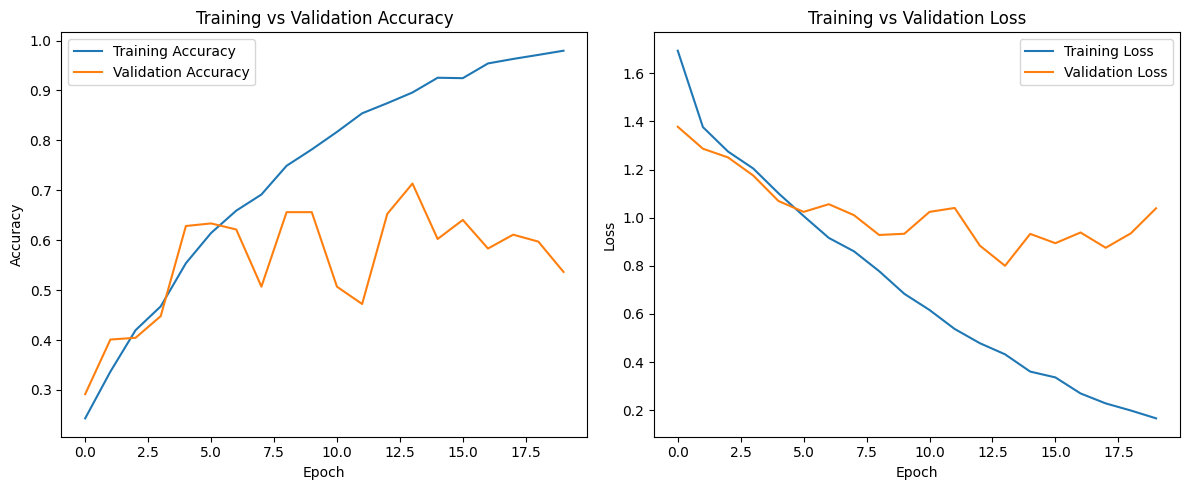

In [22]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Confusion Matrix

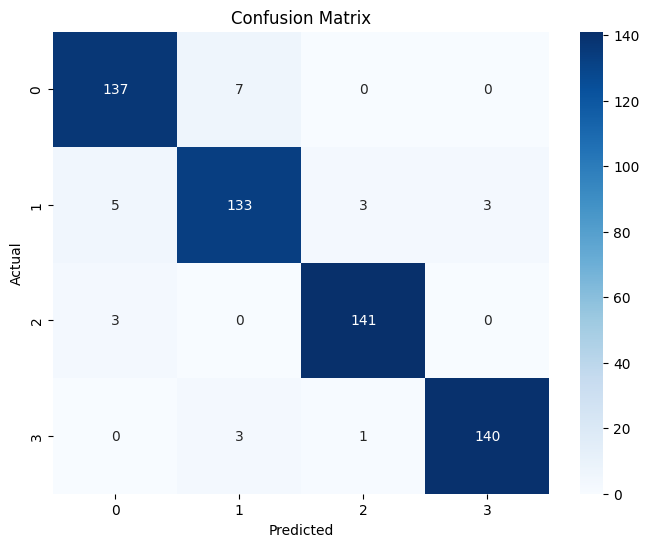

In [23]:

cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


## PCA Cumulative Explained Variance

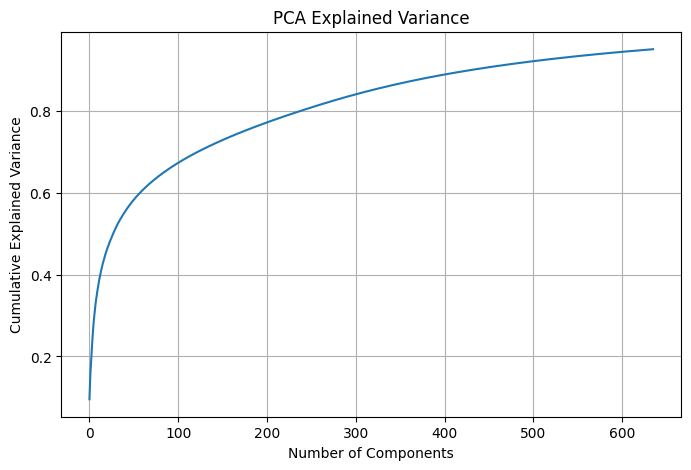

In [25]:

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

plt.grid(True)
plt.show()
